# Nuisances: building physical effects into training

This notebook builds effects that the forward model leaves out into the training of a neural posterior. A
Gaussian likelihood needs a covariance, or an extra inverted parameter, for each such effect. In
simulation-based inference, each effect is a few lines of code that perturb a seismogram. The network is trained
on simulations that carry the effect, and the posterior marginalises it (averages over it). Hu et al. (2025,
Seismica, "Bayesian reassessment of seismic moment tensors and their uncertainties in the Adriatic Sea region")
use station travel-time shifts to account for 3-D heterogeneity to first order, as explicit parameters of the
inversion. Here the same shifts are a nuisance drawn in training and marginalised by the posterior.

The setting is the 2019 Ridgecrest foreshock (Mw 6.4) at six of the stations of the ObsPy example, 2-4 degrees
away, at 20-50 s, with the source at the GCMT centroid. The forward model is an Instaseis database that resolves
20 s periods, such as `prem_a_20s`. Section 5 trains two small networks on the GPU, a few minutes in all.

In [1]:
import os

import yaml
from obspy import read_events, read_inventory

from seismo_sbi.moment_tensor.quakeml import moment_tensor_from_tensor, source_location_from_origin
from seismo_sbi.simulators.instaseis.simulator import InstaseisSourceSimulator
from seismo_sbi.simulators.receivers import Receivers

DATABASE = os.environ.get("INSTASEIS_DB_20S", "/data/shared/prem_a_20s")
CONFIG_PATH = "configs/nuisances_ridgecrest.yaml"
SAMPLING_RATE_HZ = 0.5
config_block = yaml.safe_load(open(CONFIG_PATH))
station_names = [line.split()[0] for line in open("configs/ridgecrest_stations.txt")]
receivers = Receivers(receivers=[receiver for receiver in Receivers.from_inventory(
    read_inventory("data/ridgecrest/stations.xml.gz")) if receiver.station_name in station_names])

catalogue = read_events("data/ridgecrest/events.xml.gz")
gcmt = next(m for event in catalogue for m in event.focal_mechanisms if m.creation_info and m.creation_info.author == "GCMT")
moment_tensor = moment_tensor_from_tensor(gcmt.moment_tensor.tensor)
centroid = source_location_from_origin(gcmt.moment_tensor.derived_origin_id.get_referred_object(),
                                       origin_time_utc=catalogue[0].preferred_origin().time)
simulator = InstaseisSourceSimulator(DATABASE, components="ZEN", receivers=receivers, seismogram_duration_in_s=350.0,
                                     synthetics_processing=config_block["seismic_context"]["processing"])
simulate = lambda **extra: simulator.run_simulation({"source_location": list(centroid),
                                                     "moment_tensor": list(moment_tensor), **extra})[1]
clean = simulate()
print(receivers, f"; centroid {centroid.depth} km, {centroid.time_shift} s after the hypocentre")

Receivers(6 stations: PDM, SMR, WELL, Q09A, SHP, BPH05) ; centroid 12.7 km, 9.4 s after the hypocentre


The six stations (triangles) and the GCMT centroid (star). The stations lie 2-4 degrees from the centroid on
all sides. SMR, BPH05, PDM and SHP are the four that the site nuisance below treats as basin stations.

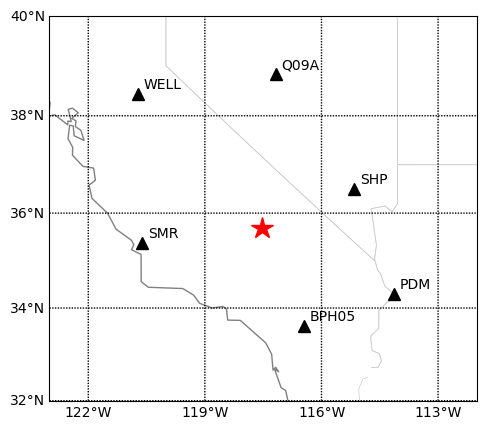

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

fig, ax = plt.subplots(figsize=(6, 5))
region = Basemap(projection="merc", llcrnrlat=32, urcrnrlat=40, llcrnrlon=-123, urcrnrlon=-112, resolution="l", ax=ax)
region.drawcoastlines(color="0.5")
region.drawstates(color="0.8")
region.drawparallels(range(32, 41, 2), labels=[1, 0, 0, 0]), region.drawmeridians(range(-122, -111, 3), labels=[0, 0, 0, 1])
for receiver in receivers:
    x, y = region(receiver.longitude, receiver.latitude)
    ax.plot(x, y, "k^", ms=8), ax.annotate(receiver.station_name, (x, y), xytext=(4, 4), textcoords="offset points")
ax.plot(*region(centroid.longitude, centroid.latitude), "r*", ms=16)
plt.show()

## The built-in effects

Each row of the figure is one effect, drawn 20 times (thin coloured lines) over the clean synthetic (black), on
the north component at the nearest and the farthest station. The source-duration draws are drawn over the GCMT
half-duration. The widths are of the size measured for regional records at 20-50 s against one-dimensional
synthetics. An overstated width puts real data outside what the network has seen.

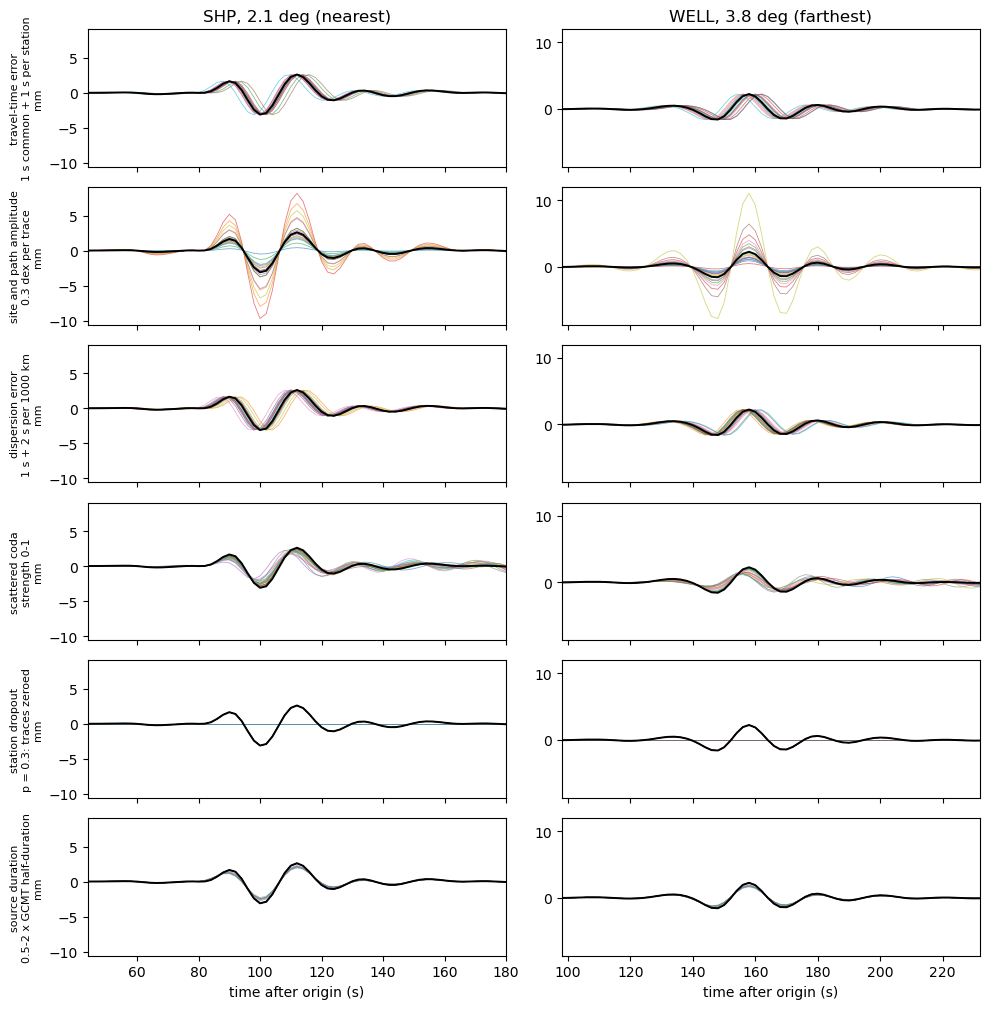

In [3]:
import numpy as np

from seismo_sbi.nuisance_effects.amplitude_effect import AmplitudeErrorEffect
from seismo_sbi.nuisance_effects.dispersion_effect import DispersionSpreadEffect
from seismo_sbi.nuisance_effects.dropout_effects import InstrumentDropoutEffect
from seismo_sbi.nuisance_effects.scattering_coda_effect import ScatteringCodaEffect
from seismo_sbi.nuisance_effects.time_shift_effect import TimeShiftErrorEffect

source = dict(source_latitude=centroid.latitude, source_longitude=centroid.longitude)
EFFECTS = [
    ("travel-time error\n1 s common + 1 s per station",
     TimeShiftErrorEffect(SAMPLING_RATE_HZ, gaussian_sigma=1.0, common_offset_dist="gaussian", common_offset_sigma=1.0),
     dict(time_shift_error=1.0)),
    ("site and path amplitude\n0.3 dex per trace",
     AmplitudeErrorEffect(distribution="lognormal", log_sigma_dex=0.3, per_component=True, always_on=True),
     dict(amplitude_error=1.0)),
    ("dispersion error\n1 s + 2 s per 1000 km",
     DispersionSpreadEffect(SAMPLING_RATE_HZ, sigma_intercept_s=[1.0] * 4, sigma_per_1000km_s=[2.0] * 4, **source),
     dict(dispersion_spread=1.0)),
    ("scattered coda\nstrength 0-1", ScatteringCodaEffect(alpha_range=(0.0, 1.0), mode="stahler"),
     dict(scattering_coda=1.0)),
    ("station dropout\np = 0.3: traces zeroed", InstrumentDropoutEffect(), dict(instrument_dropout=0.3)),
]
np.random.seed(0)
draws = {label: [effect(clean, receivers, **activation) for _ in range(20)] for label, effect, activation in EFFECTS}
references = {label: clean for label in draws}
stf_label = "source duration\n0.5-2 x GCMT half-duration"
draws[stf_label] = [simulate(stf_duration=factor) for factor in np.random.uniform(0.5, 2.0, 20)]
references[stf_label] = simulate(stf_duration=1.0)

time_s = np.arange(len(clean["SHP"]["Z"])) / SAMPLING_RATE_HZ - 60.0
fig, axes = plt.subplots(len(draws), 2, figsize=(10, 1.7 * len(draws)), sharex="col", sharey="col")
for column, (station, label) in enumerate([("SHP", "SHP, 2.1 deg (nearest)"), ("WELL", "WELL, 3.8 deg (farthest)")]):
    energetic = time_s[np.abs(clean[station]["N"]) > 0.05 * np.abs(clean[station]["N"]).max()]
    for row, (effect_label, maps) in zip(axes, draws.items()):
        for perturbed in maps:
            row[column].plot(time_s, perturbed[station]["N"] * 1e3, lw=0.6, alpha=0.6)
        row[column].plot(time_s, references[effect_label][station]["N"] * 1e3, "k", lw=1.4)
        row[0].set_ylabel(effect_label + "\nmm", fontsize=8)
    axes[0, column].set_title(label)
    axes[-1, column].set_xlabel("time after origin (s)")
    axes[-1, column].set_xlim(energetic.min() - 20, energetic.max() + 20)
fig.tight_layout()
plt.show()

## Simulation stage or training stage

The same effect can be baked into the stored simulations (`stage: simulation`) or drawn afresh every time the
data loader serves a simulation (`stage: training_augmentation`). Baking costs nothing at training time and
suits effects that need the source or are slow. Drawing afresh shows the network a new realisation every epoch.
The next cell prints the travel-time block in both forms and counts the distinct realisations each stage gives
over 20 epochs. The figure below shows the two stages in the path from a prior draw to a training pair: the
simulation-stage nuisances enter the forward model and are stored with the seismograms, and the training-stage
nuisances and the noise are applied by the dataloader.

![The two nuisance stages between a prior draw and a training pair](assets/nuisance_stages.png)

In [4]:
for stage in ("simulation", "training_augmentation"):
    block = {"time_shift_error": {**config_block["parameters"]["nuisance"]["time_shift_error"], "stage": stage}}
    print(yaml.safe_dump(block, default_flow_style=None, sort_keys=False))
n_simulations = config_block["simulations"]["num_simulations"]
print(f"distinct travel-time realisations seen in 20 epochs of {n_simulations} simulations: "
      f"{n_simulations} at the simulation stage, {20 * n_simulations} at the training stage")

time_shift_error:
  fiducial: [1.0]
  bounds: [0.0, 1.0]
  gaussian_sigma: 1.0
  stage: simulation

time_shift_error:
  fiducial: [1.0]
  bounds: [0.0, 1.0]
  gaussian_sigma: 1.0
  stage: training_augmentation

distinct travel-time realisations seen in 20 epochs of 2000 simulations: 2000 at the simulation stage, 40000 at the training stage


## A nuisance of your own: a per-station site transfer function

A site transfer function is the ratio of the motion at a station to the motion the same wave would produce on
rock. Soft sediments over stiffer rock amplify it near their fundamental frequency $f_0 = V_S / 4H$ and leave
periods much longer than $4H/V_S$ alone. In practice each station's $f_0$ and peak amplification are constrained
beforehand, from horizontal-to-vertical spectral ratios, coda site terms or borehole pairs, with uncertainties.
At 20-50 s only deep sedimentary basins matter. A basin 5-7 km deep with $V_S \approx 1.6$ km/s resonates near
0.06-0.08 Hz and amplifies 20-50 s waves by up to 2-3 at the short-period end, with a phase delay. The station
values below are illustrative, not measured: they suppose that SMR, BPH05, PDM and SHP sit on such basins. The
model is a damped soft layer over a half-space at vertical incidence, applied to all three components, which is
a simplification.

The next cell defines the effect. It subclasses `SeismogramEffect`, reads its per-station constraints from its
configuration block (a station map with an optional `"default"`), and is registered under a key a configuration
can name.

site_response:
  fiducial: [1.0]
  bounds: [0.0, 1.0]
  stage: training_augmentation
  resonance_hz: {SMR: 0.07, BPH05: 0.06, PDM: 0.08, SHP: 0.075}
  resonance_sigma_hz: {default: 0.01}
  peak_gain: {SMR: 3.5, BPH05: 4.0, PDM: 3.0, SHP: 3.0}
  peak_gain_sigma: {default: 0.3}



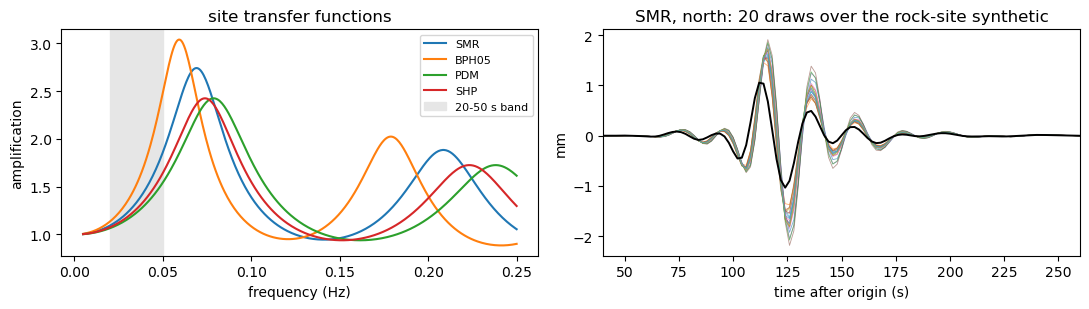

In [5]:
from seismo_sbi.nuisance_effects.post_processing import EFFECT_REGISTRY, register_nuisance_effect
from seismo_sbi.nuisance_effects.seismogram_effect import SeismogramEffect, per_station, station_value


class SiteResponseEffect(SeismogramEffect):
    """Each constrained station's traces through a soft-layer site transfer function, its fundamental frequency
    (Hz) and peak gain drawn from normal distributions per station; unconstrained stations are untouched."""

    def __init__(self, sampling_rate, resonance_hz, resonance_sigma_hz, peak_gain, peak_gain_sigma, damping=0.05):
        self.sampling_rate, self.damping = float(sampling_rate), float(damping)
        self.resonance_hz, self.resonance_sigma_hz = per_station(resonance_hz), per_station(resonance_sigma_hz)
        self.peak_gain, self.peak_gain_sigma = per_station(peak_gain), per_station(peak_gain_sigma)

    def transfer_function(self, frequency_hz, resonance_hz, peak_gain):
        phase = 0.5 * np.pi * frequency_hz / resonance_hz * (1 - 1j * self.damping)
        return 1 / (np.cos(phase) + 1j * np.sin(phase) / peak_gain)

    def __call__(self, seismograms_map, receivers, *, site_response=None, **_ignored):
        if not site_response:
            return seismograms_map
        result = {}
        for station, components in seismograms_map.items():
            resonance_hz = station_value(self.resonance_hz, station, None)
            if resonance_hz is None:
                result[station] = components
                continue
            response = self.transfer_function(
                np.fft.rfftfreq(len(next(iter(components.values()))), 1 / self.sampling_rate),
                np.random.normal(resonance_hz, station_value(self.resonance_sigma_hz, station, 0.0)),
                np.random.normal(station_value(self.peak_gain, station, 1.0), station_value(self.peak_gain_sigma, station, 0.0)))
            result[station] = {component: np.fft.irfft(np.fft.rfft(trace) * response, len(trace))
                               for component, trace in components.items()}
        return result


if "site_response" not in EFFECT_REGISTRY:
    register_nuisance_effect("site_response", SiteResponseEffect, stages=("simulation", "training_augmentation"),
                             needs_sampling_rate=True)
site_block = {"fiducial": [1.0], "bounds": [0.0, 1.0], "stage": "training_augmentation",
              "resonance_hz": {"SMR": 0.07, "BPH05": 0.06, "PDM": 0.08, "SHP": 0.075}, "resonance_sigma_hz": {"default": 0.01},
              "peak_gain": {"SMR": 3.5, "BPH05": 4.0, "PDM": 3.0, "SHP": 3.0}, "peak_gain_sigma": {"default": 0.3}}
print(yaml.safe_dump({"site_response": site_block}, default_flow_style=None, sort_keys=False))

site = SiteResponseEffect(SAMPLING_RATE_HZ, **{k: v for k, v in site_block.items() if k not in ("fiducial", "bounds", "stage")})
frequency_hz = np.linspace(0.005, 0.25, 400)
fig, (ax_gain, ax_trace) = plt.subplots(1, 2, figsize=(11, 3.2))
for station in ("SMR", "BPH05", "PDM", "SHP"):
    gain = np.abs(site.transfer_function(frequency_hz, site.resonance_hz[station], site.peak_gain[station]))
    ax_gain.plot(frequency_hz, gain, label=station)
ax_gain.axvspan(0.02, 0.05, color="0.9", label="20-50 s band")
ax_gain.set(xlabel="frequency (Hz)", ylabel="amplification", title="site transfer functions")
ax_gain.legend(fontsize=8)
np.random.seed(1)
for _ in range(20):
    ax_trace.plot(time_s, site(clean, receivers, site_response=1.0)["SMR"]["N"] * 1e3, lw=0.6, alpha=0.6)
ax_trace.plot(time_s, clean["SMR"]["N"] * 1e3, "k", lw=1.4)
ax_trace.set(xlabel="time after origin (s)", ylabel="mm", title="SMR, north: 20 draws over the rock-site synthetic",
             xlim=(40, 260))
fig.tight_layout()
plt.show()

## The effect on coverage

Two small networks are trained on the same 2000 simulations, with sensor noise and the travel-time error. One
of them also trains with the site nuisance. Both are then given held-out simulations that carry the site effect,
as real records from those stations would. The next cells build the two training sets, train the two networks,
and count how often the true source falls inside each posterior's 95 % highest-density region. A calibrated
posterior covers it about 95 % of the time.

In [6]:
import tempfile
from copy import deepcopy
from dataclasses import replace
from pathlib import Path

import torch

from seismo_sbi.nuisance_effects.post_processing import PostProcessingChain
from seismo_sbi.sbi.configuration import SBI_Configuration
from seismo_sbi.sbi.datasets.training_data import build_pipeline, generate_training_dataset, prepare_training_data

scratch = Path(tempfile.mkdtemp())
config_with_site = deepcopy(config_block)
config_with_site["parameters"]["nuisance"]["site_response"] = site_block
config_with_site["simulations"]["sampling_method"]["site_response"] = "constant"
config_path = scratch / "nuisances_with_site.yaml"
config_path.write_text(yaml.safe_dump(config_with_site))
config = SBI_Configuration.from_file(config_path, output_directory=scratch, database_path=DATABASE)
training = config.training.apply_overrides(epochs=40)

np.random.seed(2)
torch.manual_seed(2)
pipeline = build_pipeline(config, str(config_path))
simulation_paths = generate_training_dataset(pipeline, config, training.skip_compression_stencil)
data_with_site = prepare_training_data(pipeline, config, simulation_paths, training)
data_without_site = replace(data_with_site, augmentation_chain=PostProcessingChain(
    [effect for effect in data_with_site.augmentation_chain.effects if not isinstance(effect, SiteResponseEffect)]))
print([type(effect).__name__ for effect in data_with_site.augmentation_chain.effects], "against",
      [type(effect).__name__ for effect in data_without_site.augmentation_chain.effects])

Training dataset ready: 2000 simulations at /tmp/tmp_cylcvha/sims/nuisances_ridgecrest/results
Training-time nuisance augmentation: ['site_response', 'time_shift_error']
Post-noise augmentation: none
Moment-tensor scaling: linear
['SiteResponseEffect', 'TimeShiftErrorEffect'] against ['TimeShiftErrorEffect']


In [7]:
from seismo_sbi.sbi.npe.training.train import CompressionTrainer, attach_loggers

posteriors = {}
for name, data in (("with the site nuisance", data_with_site), ("without it", data_without_site)):
    trainer = CompressionTrainer.from_training_data(replace(training, model_dim=32), data, layers=1)
    run_name = name.replace(" ", "_")
    trainer.train(run_name, epochs=training.epochs, output_path=pipeline.models_output_path,
                  dataloader_args=training.dataloader_args(pipeline, data), enable_progress_bar=False,
                  logger=attach_loggers(training.logging, pipeline.models_output_path / run_name))
    posteriors[name] = trainer.build_posterior()

CSV metrics logging to /tmp/tmp_cylcvha/nuisances_ridgecrest/results/with_the_site_nuisance/metrics.csv
Found 2000 simulations matching *.h5 under /tmp/tmp_cylcvha/sims/nuisances_ridgecrest/results
CSV metrics logging to /tmp/tmp_cylcvha/nuisances_ridgecrest/results/without_it/metrics.csv
Found 2000 simulations matching *.h5 under /tmp/tmp_cylcvha/sims/nuisances_ridgecrest/results


Found 2000 simulations matching *.h5 under /tmp/tmp_cylcvha/sims/nuisances_ridgecrest/results
with the site nuisance   the 95 % region holds the true source in 97 % of 200 held-out events
without it               the 95 % region holds the true source in 74 % of 200 held-out events


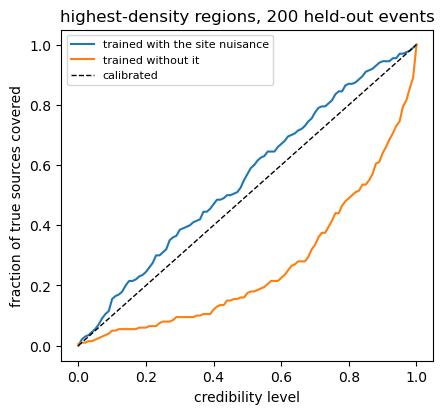

In [8]:
from seismo_sbi.sbi.npe.data.dataloading import TorchSimulationDataset

held_out = TorchSimulationDataset(**training.dataset_args(pipeline, data_with_site))
first_held_out = int(training.batch.train_fraction * len(held_out))
np.random.seed(3)
torch.manual_seed(3)
coverage, levels = {}, {}
for name, posterior in posteriors.items():
    device = next(posterior.posterior_estimator.parameters()).device
    inside, levels[name] = [], []
    for index in range(first_held_out, len(held_out)):
        theta, x = (tensor.float().to(device)[None] for tensor in held_out[index][:2])
        samples = posterior.sample((1000,), x=x, show_progress_bars=False)
        log_q = posterior.log_prob(samples, x=x, norm_posterior=False)
        log_q_truth = posterior.log_prob(theta, x=x, norm_posterior=False)
        inside.append(bool(log_q_truth > torch.quantile(log_q, 0.05)))
        levels[name].append(float(torch.mean((log_q > log_q_truth).float())))
    coverage[name] = np.mean(inside)
    print(f"{name:24s} the 95 % region holds the true source in {100 * coverage[name]:.0f} % of "
          f"{len(inside)} held-out events")
assert coverage["with the site nuisance"] > coverage["without it"] + 0.1

credibility = np.linspace(0, 1, 101)
fig, ax = plt.subplots(figsize=(4.8, 4.3))
for name, colour in (("with the site nuisance", "C0"), ("without it", "C1")):
    ax.plot(credibility, [np.mean(np.array(levels[name]) <= level) for level in credibility], color=colour,
            label=f"trained {name}")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="calibrated")
ax.set(xlabel="credibility level", ylabel="fraction of true sources covered",
       title=f"highest-density regions, {len(levels[name])} held-out events")
ax.legend(fontsize=8)
plt.show()

The network that never saw the site effect reads the basin stations' amplification and delay as a property of
the source. Its 95 % region misses the true source far more often than one time in twenty. The network trained
with the nuisance marginalises the effect, and its coverage is at or above nominal. A briefly trained network's
posterior is somewhat too wide. The assertion is deliberately the weakest honest one: training with the nuisance
raises coverage by at least ten points. Across runs of this notebook, the coverage with the nuisance held at 95
to 99 %, while the coverage without it varied widely between trainings, from 18 to 74 %. The ordering never
reversed. That spread is training variance, from a few minutes of training on 2000 simulations. The curves give
the same picture at every credibility level: the network trained with the nuisance lies on or above the diagonal,
slightly conservative, and the one trained without it lies well below it, overconfident.

## One held-out event

The first held-out simulation whose true source lies inside the 95 % region of the network trained with the site
nuisance and outside that of the network trained without it. Left: both posteriors on the lune (68 and 95 %
regions) and the true source. Right: the simulated vertical traces at the two basin stations SMR and BPH05
against the rock-site synthetics of 20 tensors drawn from each posterior. On the lune the two posteriors overlap
and both reach the true source. The difference is in six dimensions: the network trained with the nuisance
returns a tight bundle of tensors (blue) that holds the true one, and the network trained without it returns a
bundle that varies in shape and timing (orange) and still misses it. Both bundles arrive earlier and smaller than
the record, which carries the basin's delay and amplification. Only one network allows for them.

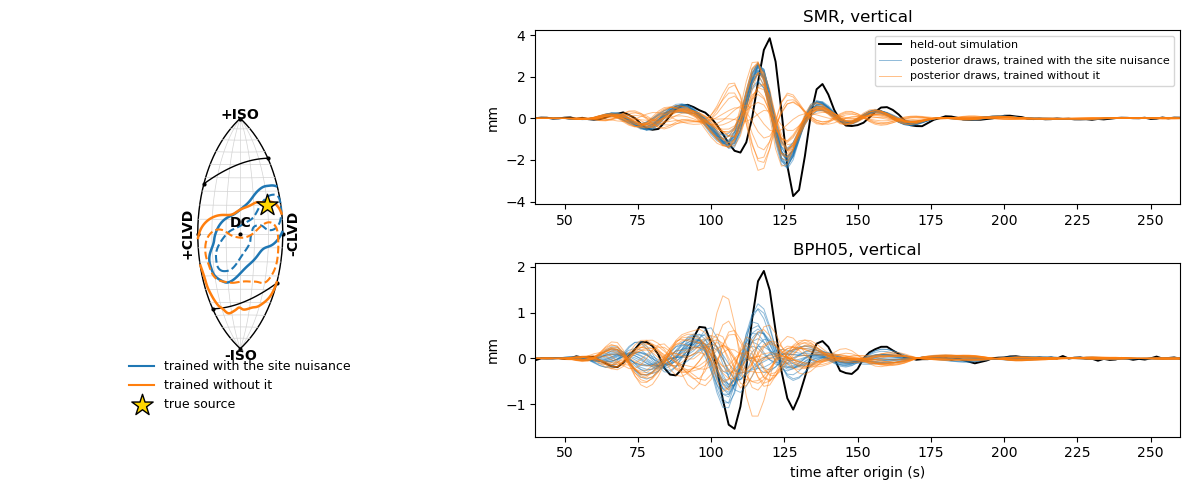

In [9]:
from seismo_sbi.moment_tensor.lune_angles import mts6_to_gamma_delta
from seismo_sbi.plotting.lune import plot_kde_contours_on_lune, plot_lune_frame, plot_scatter_on_lune


def holds_truth(posterior, theta, x, n_draws=1000):
    """Whether ``posterior``'s 95 % highest-density region for ``x`` holds ``theta`` (both in the network's units)."""
    log_q = posterior.log_prob(posterior.sample((n_draws,), x=x, show_progress_bars=False), x=x, norm_posterior=False)
    return bool(posterior.log_prob(theta, x=x, norm_posterior=False) > torch.quantile(log_q, 0.05))

np.random.seed(4)
torch.manual_seed(4)
for index in range(first_held_out, len(held_out)):
    theta, x = (tensor.float().to(device)[None] for tensor in held_out[index][:2])
    if holds_truth(posteriors["with the site nuisance"], theta, x) and not holds_truth(posteriors["without it"], theta, x):
        break
scalers = {"with the site nuisance": data_with_site.data_scaler, "without it": data_without_site.data_scaler}
truth = data_with_site.data_scaler.inverse_transform(theta.cpu().numpy().astype(float))[0]
clouds = {name: scalers[name].inverse_transform(posterior.sample((5000,), x=x, show_progress_bars=False).cpu().numpy().astype(float))
          for name, posterior in posteriors.items()}

fig = plt.figure(figsize=(12, 5))
grid = fig.add_gridspec(2, 2, width_ratios=[1, 1.4])
ax_lune = fig.add_subplot(grid[:, 0])
lune = plot_lune_frame(ax_lune)
colours = {"with the site nuisance": "C0", "without it": "C1"}
for name, cloud in clouds.items():
    plot_kde_contours_on_lune(ax_lune, lune, *mts6_to_gamma_delta(cloud), colors=colours[name])
    ax_lune.plot([], [], color=colours[name], label=f"trained {name}")
plot_scatter_on_lune(ax_lune, lune, *mts6_to_gamma_delta(truth[None]), marker="*", s=260, facecolor="gold",
                     edgecolor="k", zorder=12, label="true source")
ax_lune.legend(loc="upper center", bbox_to_anchor=(0.5, 0.0), fontsize=9, frameon=False)
observation = x[0].cpu().numpy()
station_names = [receiver.station_name for receiver in receivers]
for row, station in enumerate(("SMR", "BPH05")):
    ax = fig.add_subplot(grid[row, 1])
    ax.plot(time_s, observation[station_names.index(station), 0] * 1e3, "k", lw=1.4, label="held-out simulation")
    for name, cloud in clouds.items():
        for draw, moment_tensor_draw in enumerate(cloud[:20]):
            ax.plot(time_s, simulate(moment_tensor=list(moment_tensor_draw))[station]["Z"] * 1e3, color=colours[name],
                    lw=0.7, alpha=0.5, label=f"posterior draws, trained {name}" if draw == 0 else None)
    ax.set(title=f"{station}, vertical", ylabel="mm", xlim=(40, 260))
ax.set_xlabel("time after origin (s)")
fig.axes[1].legend(fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()